# Why Jupyterlab

Jupyter notebooks are great for developing data pipelines and tooling. You can easily load, transform, and inspect data.

For example

In [1]:
#| code-fold: true
#| code-summary: Formatting
import pandas as pd

pd.options.display.max_columns = None
pd.options.display.max_colwidth = 150

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

chicago_boundary = gpd.read_file("https://data.cityofchicago.org/api/geospatial/qqq8-j68g?method=export&format=GeoJSON")
chicago_park_events = gpd.read_file("https://data.cityofchicago.org/api/geospatial/tn7v-6rnw?method=export&format=GeoJSON")

print(chicago_park_events.shape)
display(chicago_park_events.head(2))

(7815, 28)


,start_date,latitude,zip,description,registration_date,location_notes,restrictions,activity_type,age_range,season,longitude,registration_link,activity_id,end_date,image_link,location_facility,address,category,information_link,title,event_cancelled,type,movie_title,movie_rating,zone,date_notes,fee,geometry
0,2026-01-09 15:45:00,42.0098764,60631,"January 9, 2026 to March 13, 2026",2025-12-08 15:00:00,None,None,Instruction,Youth,None,-87.8072766,None,548971,2026-03-13 16:30:00,None,Brooks (Oscar) Park,7100 N. Harlem Ave.,Sports - Basketball,http://apm.activecommunities.com/chicagoparkdistrict/Activity_Search/548971,Basketball at Brooks,None,Program,None,None,None,"From January 9, 2026 to March 13, 2026 Each Friday from 3:45pm to 4:30pm",21,POINT (-87.80728 42.00988)
1,2026-01-08 16:30:00,41.9526427,60634,"January 8, 2026 to March 12, 2026",2025-12-08 15:00:00,None,None,Instruction,Early Childhood,None,-87.7851891,None,550704,2026-03-12 17:30:00,None,Merrimac Park,6343 W. Irving Park Rd.,Tumbling,http://apm.activecommunities.com/chicagoparkdistrict/Activity_Search/550704,Tiny Tot Tumbling at Merrimac,None,Program,None,None,None,"From January 8, 2026 to March 12, 2026 Each Thursday from 4:30pm to 5:30pm",10,POINT (-87.78519 41.95264)


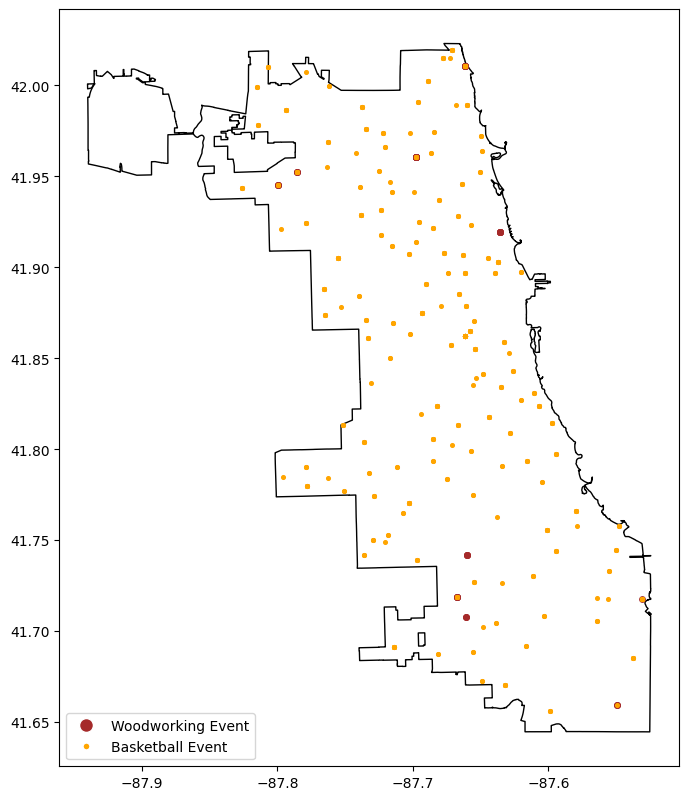

In [3]:
woodworking_events = chicago_park_events.loc[chicago_park_events["category"] == "Woodworking"]
basketball_events = chicago_park_events.loc[chicago_park_events["category"] == "Sports - Basketball"]

fig, ax = plt.subplots(figsize=(8,10))
ax = chicago_boundary.plot(facecolor="none", ax=ax)
ax = woodworking_events.plot(markersize=15, ax=ax, color="brown")
ax = basketball_events.plot(markersize=7, ax=ax, color="orange")
legend_elements = [
    Line2D([0], [0], marker="o", color='w', markerfacecolor="brown", markersize=10, label="Woodworking Event"),
    Line2D([0], [0], marker=".", color='w', markerfacecolor="orange", markersize=10, label="Basketball Event"),
]
_ = ax.legend(handles=legend_elements, loc="lower left")

# Setup

I've worked through a number of different setups, but I've used this setup for two years for my general analysis and development work without any frustrations.

I use the excellent [uv python project manager](https://github.com/astral-sh/uv) to manage dependencies and run the server.

I have all of my projects in a directory `~/projects`, and I make a directory for my `jupyter` environment.

I can set up the project, install dependencies, and generate a config file via

```console
mkdir -p ~/projects/jupyter && cd ~/projects/juypyter
uv init
uv add jupyterlab geopandas matplotlib
uv run jupyter server --generate-config
```

And I can start up a server and access it via the machine I'm `ssh`-ing in from via

```console
cd ~/projects
uv --project /jupyter run jupyterlab --ip 0.0.0.0 --no-browser
```

In [4]:
!ls -la ~/projects/jupyter

total 568
drwxrwxr-x  4 matt matt   4096 Dec  6 12:39 .
drwxrwxr-x 61 matt matt   4096 Jan 30 22:46 ..
drwxrwxr-x  7 matt matt   4096 Dec  6 12:39 .git
-rw-rw-r--  1 matt matt    109 Dec  6 12:39 .gitignore
-rw-rw-r--  1 matt matt     85 Dec  6 12:39 main.py
-rw-rw-r--  1 matt matt    472 Jan 31 19:48 pyproject.toml
-rw-rw-r--  1 matt matt      5 Dec  6 12:39 .python-version
-rw-rw-r--  1 matt matt      0 Dec  6 12:39 README.md
-rw-rw-r--  1 matt matt 546250 Jan 31 19:48 uv.lock
drwxrwxr-x  7 matt matt   4096 Jan 17 00:50 .venv


## Relocating .ipynb_checkpoints files

Jupyter notebooks default to automatically creating a hidden directory named `.ipynb_checkpoints` in whatever directory a the notebook is in, and in that directory is periodically autosaves backups of a notebook. In development workflows (where something automatically detects files through subdirectories), this can be particularly annoying.

Fortunately, we can reconfigure that. In the `~/.jupyter/jupyter_server_config.py` file that we generated above (via the `uv run jupyter server --generate-config` command), add these lines around the `c = get_config()` line to create a directory to shunt checkpoint files to and to actually route checkpoint files there.

In [5]:
!cat ~/.jupyter/jupyter_server_config.py | head -n 12

from pathlib import Path

# Configuration file for jupyter-server.

CHECKPOINT_DIR = Path("~").joinpath("projects", ".temp", ".jupyter", ".checkpoints").expanduser()
if not CHECKPOINT_DIR.is_dir():
    CHECKPOINT_DIR.mkdir(parents=True)

c = get_config()  #noqa

c.FileCheckpoints.checkpoint_dir = str(CHECKPOINT_DIR)



## Showing hidden files

The other annoying `jupyter` default is that hidden files (like `.env` files) are not displayed in the file browser. To correct this, uncomment the `...ContentsManager.allow_hidden` lines and make sure they're set to `True`.

In [6]:
!grep -n "c.*allow_hidden" ~/.jupyter/jupyter_server_config.py

1048:c.ContentsManager.allow_hidden = True
1175:c.FileContentsManager.allow_hidden = True
1263:c.AsyncContentsManager.allow_hidden = True
1339:c.AsyncFileContentsManager.allow_hidden = True


# Summary

That's basically all it takes to get up and running. After the above setup, you only have to run this (then copy the displayed URL to a browser).

```console
cd ~/projects
uv --project /jupyter run jupyterlab --ip 0.0.0.0 --no-browser
```

And to install new dependencies, just use this pattern. It will be accessible in the default `Python 3 (ipykernel)` notebook option.

```console
cd ~/projects/jupyter
uv add <whatever dependencies you need>
```